# LangGraph Tutorial

## One Agent and Multiple Tools v.1
Invoke the LLM with binded Tools
* Start with an LLM with tools, `invoke_LLM`
* LLM makes a decision to call a function/tool
* If so, then `action` to call tool (ToolExecutor)
* Then call LLM with the tool output added to messages (`state`)

#### Initiate LLM 

In [21]:


from langchain_openai import ChatOpenAI

from dotenv import load_dotenv
import os

load_dotenv()



model = os.environ.get("MODEL")
gateway_base_url = os.environ.get("GATEWAY_BASE_URL")
gateway_api_key = os.environ.get("GATEWAY_API_KEY")

llm = ChatOpenAI(
  model_name=model,
  temperature=0.1,
  max_tokens=4096,
  openai_api_base=gateway_base_url,
  openai_api_key=gateway_api_key,
)


#### Define simple tools using LangChain

This @tool decorator is the simplest way to define a custom tool. <br> 
The decorator uses the function name as the tool name by default, but this can be overridden <br> 
by passing a string as the first argument. Additionally, the decorator will use the <br> 
function's docstring as the tool's description - so a docstring MUST be provided.

In [22]:
from langchain.tools import tool


# setup the simple tools using LangChain tool decorator
@tool
def add(a: int, b: int) -> int:
    """Add two numbers."""
    return a + b


@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers."""
    return a * b


@tool
def square(a: int) -> int:
    """Calculates the square of a number."""
    a = int(a)
    return a * a

# setup the toolkit
toolkit = [add, multiply, square]



Inspecting the tools

In [23]:
print(multiply.name)
print(multiply.description)
print(multiply.args)
print(multiply.return_direct)
print(multiply.args_schema.schema())

multiply
Multiply two numbers.
{'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}
False
{'description': 'Multiply two numbers.', 'properties': {'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}, 'required': ['a', 'b'], 'title': 'multiply', 'type': 'object'}


In [24]:
llm_w_tools = llm.bind_tools(toolkit)
llm_output = llm_w_tools.invoke('1+1 and 2*2')

#display invocation output
print(llm_output)
#display type of message returned
print(type(llm_output))

content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 174, 'total_tokens': 234, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None, 'image_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0, 'text_tokens': None, 'image_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.1-2025-11-13', 'system_fingerprint': None, 'id': 'chatcmpl-DUwVmTxVgawapvfF41VgU9ibJ5vVz', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019d91d8-3b7b-7650-8619-3295e6a5e8a1-0' tool_calls=[{'name': 'add', 'args': {'a': 1, 'b': 1}, 'id': 'call_UlStzcN8M21GGaodiLBauwrT', 'type': 'tool_call'}, {'name': 'multiply', 'args': {'a': 2, 'b': 2}, 'id': 'call_ooSv6ccouFHC7gUN8nG02FNz', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 174, 'output_

In [25]:
print(llm_output.tool_calls)

[{'name': 'add', 'args': {'a': 1, 'b': 1}, 'id': 'call_UlStzcN8M21GGaodiLBauwrT', 'type': 'tool_call'}, {'name': 'multiply', 'args': {'a': 2, 'b': 2}, 'id': 'call_ooSv6ccouFHC7gUN8nG02FNz', 'type': 'tool_call'}]


Agent and Tool Nodes

In [26]:

#invoke LLM node
def invoke_LLM(state):
    #read the message history
    messages = state['messages']
    response = llm_w_tools.invoke(messages)
    #update messages state by appending the latest response
    return {'messages': [response]}


#### Graph State
All information we need to run the graph will be in the messages passed <br>
between the user and the AI so we only need one state variable

In [27]:
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage
from langgraph.graph import add_messages
import operator


class AgentState(TypedDict):
   #a list of messages sent between the agent and user.
   #can be a human message, can be an AI message
   #new messages will be appended to the list.
   messages: Annotated[list, add_messages]


#### Edge Logic

In [28]:
from langgraph.graph import StateGraph, END
def should_continue(state:AgentState):

    messages = state['messages']
    last_message = messages[-1]

    if last_message.tool_calls:
        return "action"
    else:
        return END
    

#### Build the Graph

In [29]:
from langgraph.graph import StateGraph,START, END
from langgraph.prebuilt.tool_node import ToolNode
# Define a new graph
workflow = StateGraph(AgentState)

# Define the two nodes we will cycle between
workflow.add_node("LLM", invoke_LLM)
# workflow.add_node("action", call_tool)
workflow.add_node("action", ToolNode(toolkit)) 

# Set the entrypoint as `agent` where we start
workflow.add_edge(START, "LLM")

# We now add a conditional edge
workflow.add_conditional_edges(
    # First, we define the start node. We use `agent`.
    # This means these are the edges taken after the `agent` node is called.
    "LLM",
    # Next, we pass in the function that will determine which node is called next.
    should_continue,
    ["action", END] 
)

# We now add a normal edge from `tools` to `agent`.
# This means that after `tools` is called, `agent` node is called next.
workflow.add_edge('action', 'LLM')

# Finally, we compile it!
# This compiles it into a LangChain Runnable,
# meaning you can use it as you would any other runnable
app = workflow.compile()

In [31]:
from langchain_core.messages import HumanMessage, SystemMessage

# Can add system message for the LLM 
system_message = SystemMessage(content="You are a helpful calculator assistant")
human_message = HumanMessage(content="what is 1+1 and 2*2")


inputs = {"messages": [system_message,human_message]}

app.invoke(inputs)

{'messages': [SystemMessage(content='You are a helpful calculator assistant', additional_kwargs={}, response_metadata={}, id='2e8c5161-32d9-40c6-a7e1-46790f97e422'),
  HumanMessage(content='what is 1+1 and 2*2', additional_kwargs={}, response_metadata={}, id='10e4d872-b1a6-4778-86b1-3ff781507312'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 187, 'total_tokens': 247, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None, 'image_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0, 'text_tokens': None, 'image_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.1-2025-11-13', 'system_fingerprint': None, 'id': 'chatcmpl-DUwZeCEuYJZDyMNImuAeoZuqaGUx6', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d91da-49d9-7

#### Visualise Agent

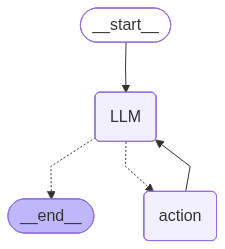

In [32]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass